#Zeitenwende: Showing in Numbers How the 2022 Russian Invasion of Ukraine Began an Arms Reshuffling Across Europe


>Clayton Greenwell
>
>Dr. Nasim Anousheh
>
>DSCI-D699 Graduate Independent Study in Data Science
>
>July 2026

In [1]:
# Google Colab instructions
#
# Runtime > Change Runtime Type > Runtime Version > 2025.07
# This cell should say you're on Python Version 3.11.

import sys
print(sys.version)

3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


##1. About the Data

An extensive amount of data cleaning was done to transform the following datasets into one clean, usable spreadsheet:

>•	SIPRI Arms Transfer Database
>
>•	SIPRI Arms Industry Database
>
>•	SIPRI Military Expenditure Database
>
>•	Geopolitical Risk Index (Caldara & Iacoviello, 2022)
>
>•	Google Maps data (*aerial_distance_moscow_km*)

The Stockholm International Peace Research Institute (SIPRI) is a globally renowned think tank known for tracking the global arms industry. Their datasets have been used in countless peer-reviewed publications.

The SIPRI datasets obtained contained missing values. Linear interpolation was the constant method used to fill these missing values when appropriate. Several features were created from calculations involving other features: *import_export_ratio, import_growth_rate, export_coverage_ratio, ME_spending_%_GDP_growth_rate,* and *export_growth_rate*. Aside from a later experiment with Gephi, all data used is broken down across the 4 years since the Russian invasion of Ukraine (2022-2025). All data is exclusive to European countries.

The cleaned dataset can be found here: https://github.com/ClaytonGreenwell/defense_spending_project/blob/main/final_submission/sipri_data1.xlsx

There are many columns in this dataset that function as a target, with an abundance of overlap:

>•	*import_TIV_millions*
>
>•	*import_export_ratio*
>
>•	*import_growth_rate*
>
>•	*export_coverage_ratio* (calculation relies on *import_TIV_millions*)
>
>•	*ME_spending_%_GDP*
>
>•	*ME_spending_%_GDP_lead_1_year*
>
>•	*ME_per_capita_in_USD*
>
>•	*ME_%_gov_budget*
>
>•	*ME_spending_%_GDP_growth_rate*

As an example, it’s understandable that a country’s arms imports (*import_TIV_millions*) will correspond directly to that country's military expenditure as a percentage of GDP (*ME_spending_%_GDP*). This overlap is true of all above-mentioned columns and is dealt with appropriately in this report.

Some of the most interesting and usable features include:

>•	*export_TIV_millions*
>
>•	*export_growth_rate*
>
>•	*aerial_distance_moscow_km*
>
>•	*GPR_index*
>
>•	*is_in_NATO?*
>
>•	*top_supplier_country*
>
>•	*is_US_top_supplier_country?*
>
>•	*companies_in_sipri_top_100*

Many countries in *companies_in_sipri_top_100* contain fractional values. This is due to joint-EU defense companies that spread operations across multiple EU countries without assigning ownership to a single state.

Some notes on the choices made for visualizations throughout this report:

>•	The definition of “Europe” includes all countries that are members of the Council of Europe.
>
>>o	Russia is included, though it was expelled from the Council in 2022.
>>
>>o	Belarus and Kosovo were included, despite not being members of the Council.
>>
>•	Five “microstates” were excluded from all visualizations:  Andorra, Liechtenstein, Monaco, San Marino, and Vatican City.
>
>•	Malta was included. Malta was not classified as a “microstate” despite its size and population for 3 reasons:
>
>>o	It is a European Union member.
>>
>>o	Unlike the other 5 microstates, Malta doesn’t have a dramatic diplomatic dependence on other states.
>>
>>o	Malta’s location in the Mediterranean Sea is strategically important from a military defense perspective.
>>
>•	Various disputed states were excluded: Northern Cyprus, Transnistria, Abkhazia, and South Ossetia.
>
>•	Article 41(2) of the Treaty on European Union prohibits the regular EU budget from being used for military defense purposes. Some EU states have contributed to a workaround agency called The European Peace Facility. The EPF purchases arms as a unified body. Many of these arms are given to Ukraine or are used to bolster a collective NATO/EU defense network (Cepparulo & Pasimeni, 2024). As this is a collective agency that operates on the fringe of the EU, it’s important to understand that imports and exports from this agency would not appear in import/export visualizations unless an actual country (like Ukraine) is receiving those arms as an import.  


In [2]:
# We'll need pycaret for creating our machine learning models later on. We'll
# need to install pycaret before we import our data, as we'll otherwise lose
# our data when restarting the session.
#
# If running this cell in your own environment, note that removing
# "> /dev/null 2>&1" will show the extended output and errors. Removing this
# will also conclude the output by manually prompting you to restart the
# session (if using Google Colab).

!pip install pycaret openpyxl > /dev/null 2>&1

In [1]:
# Due to installing pycaret, before running this cell:
# Runtime > Restart Session

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("sipri_data1.xlsx")

##2. Tableau Visualization I: Arms Exports

*Europe's Engine*

*Figure 1:*

https://public.tableau.com/app/profile/clayton.greenwell/viz/EuropeAverageAnnualArmsExportTIVs20222025/Sheet1

The above link is interactive. Here is a static image of Figure 1:

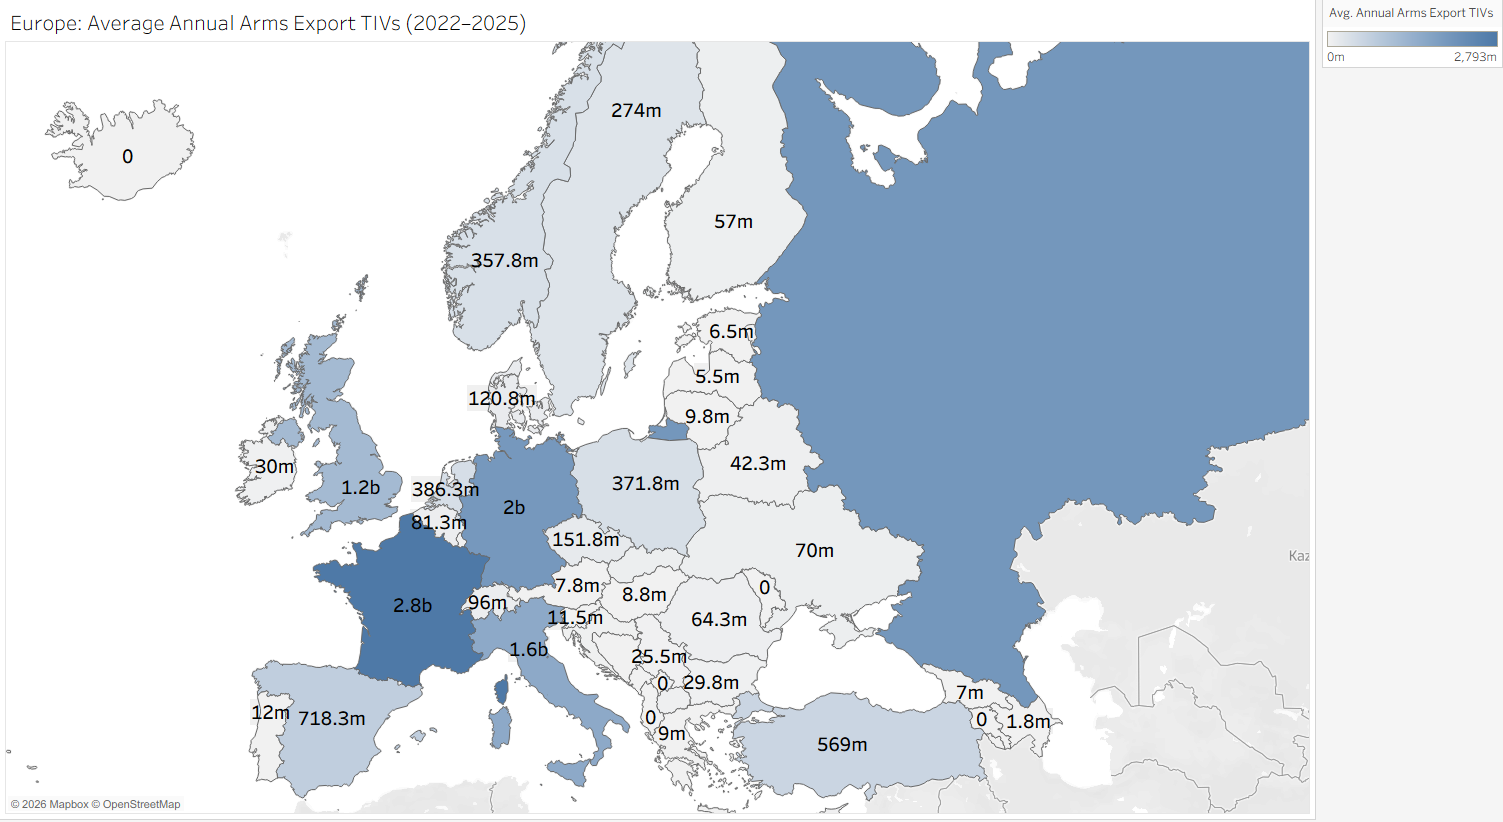

In [3]:
from IPython.display import Image, display

display(Image(filename="export_tableau.png", width=1100))

Some notes on this visualization:

>•	This visualization averages annual arms export data from 2022 – 2025. (The wider Russian ground invasion of Ukraine began in 2022).
>
>•	The unit of measurement used in this visualization is Trend Indicator Values, commonly known as TIV units. TIV units are the gold standard for arms measurements because they help normalize what would otherwise be a very difficult calculation. (Keep in mind that using euros or dollars sold wouldn’t be practical in a long-term study, as there were long periods during the Cold War that the US and USSR gave away weapons to other countries for free). As a measurement tool, TIV units standardize production costs by evaluating raw capability and resources required to build hardware (SIPRI, n.d.).
>
Germany, France, Italy, and the United Kingdom are strong European engine economies that have the capabilities to create and export an incredible number of arms. These 4 countries together have an average annual output of 7.47 billion TIV units since the start of the war. SIPRI compiles a yearly list of the Top 100 Global Defense Companies. Germany, France, Italy, and the UK have collectively comprised roughly 20% of the companies listed since the outbreak of war in 2022 (SIPRI, n.d.).

Despite tough foreign sanctions and the ongoing domestic needs of immediate warfare, Russia has managed to export an average of 2 billion TIV units a year since the start of the war. Arms sales to countries like India have helped to bolster Russia’s struggling economy (SIPRI, n.d.). On the world market, many of Russia’s most sought-after weapons rely in some small part on small components manufactured in the US, the UK, and other Western countries that are attempting to enforce sanctions and export control restrictions (George & Sandler, 2022). Export control restrictions are meant to throttle Russia’s supply of these dual-use components. Russia’s inability to access advanced computer chip technology is a critical chokepoint affecting Russia’s arms industry (George & Sandler, 2022).


##3. Tableau Visualization II: Arms Imports

*Russia Anxiety in Poland*

*Figure 2:*

https://public.tableau.com/app/profile/clayton.greenwell/viz/EuropeAverageAnnualArmsImportTIVs2022-2025/Sheet1


The above link is interactive. Here is a static image of Figure 2:

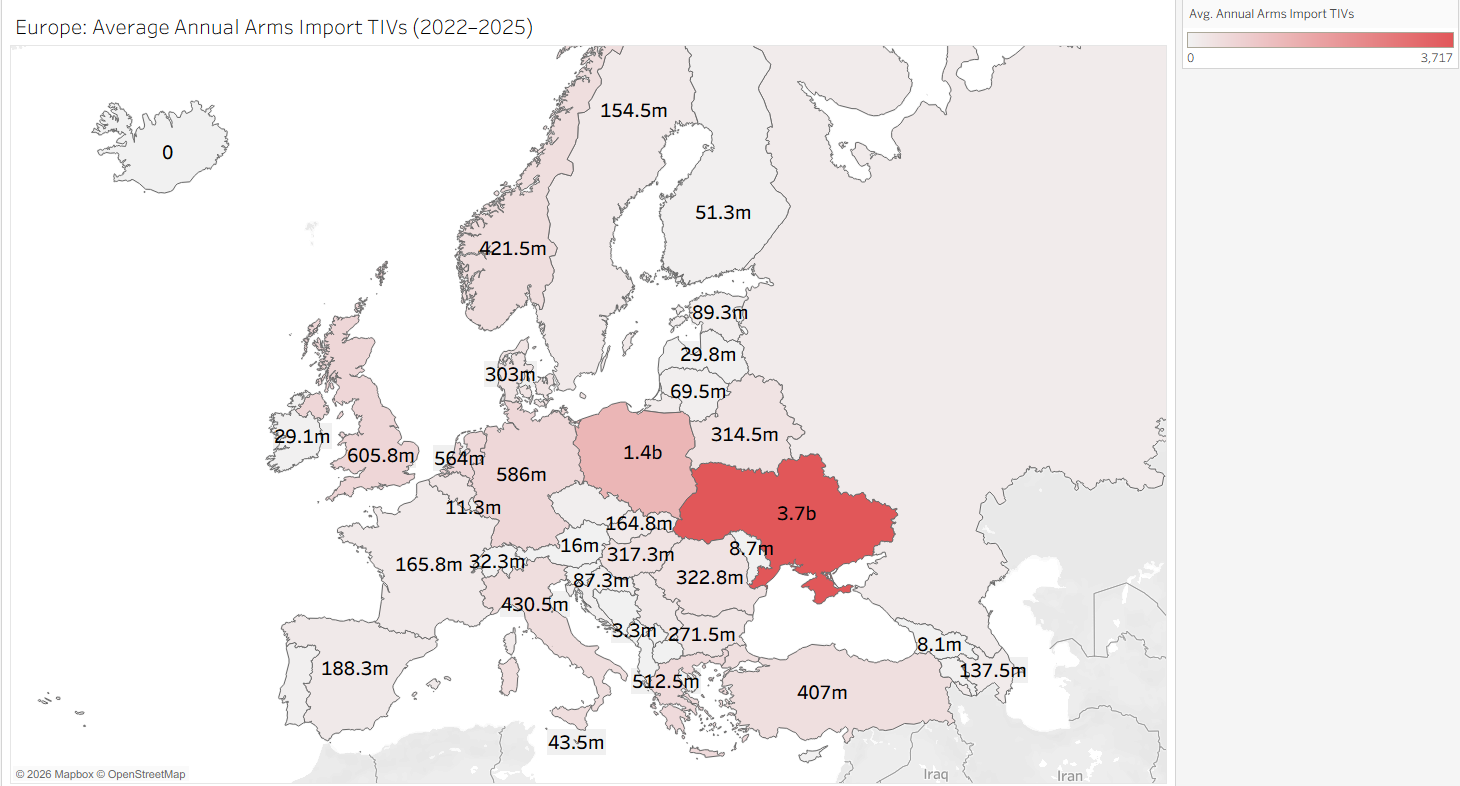

In [4]:
display(Image(filename="import_tableau.png", width=1100))

Ukraine’s massive annual import of 3.72 billion TIV units worth of arms sits as an outlier, massively tipping the color scale and leaving other countries unsaturated.

Despite this outlier, important information can be gleaned by country shading that isn’t as immediately stark. Poland’s annual average import of 1.38 billion TIV units is reflective of the emerging role that Poland now plays as Europe’s rising military power. On the surface, Poland is a country at peace containing many attributes that make war seem incredibly unlikely. A close partner of the United States, Poland is a member of NATO and therefore has considerable shielding due to NATO’s Article 5 collective defense obligation.

The bigger picture is that NATO membership alone doesn’t ease or erase recent memory. Unlike most Western European countries, Poland has a recent history of being subjected to Russian occupation and undue influence. Russia, (as its predecessor state, the USSR,) had some sort of troop presence inside Poland’s borders from 1939 to 1993, stretching 54 years of selective leverage (Nawrocki, 2023).

There exists a strong belief in Poland that Russia will use their borders to test the seriousness of NATO’s Article 5. As a country, Poland sits geographically between several pain points: a shared border with Ukraine, a shared border with Russia’s exclave of Kaliningrad, a shared border with Russia’s vassal state Belarus, and the Suwałki Gap corridor connecting the Baltic States to the rest of NATO. Seeing these four fragile border vulnerabilities, Poland has prioritized its territorial integrity, bolstering its military stockpiles in preparation for Russian maneuvering (Tian et al., 2023).

One could surmise from this visualization and the previous export visualization that it would make sense for a country like Poland to take the domestic manufacture of arms much more seriously, being that they are both at peace and in a relatively high need for dramatically high imports. This gets to one of the known realities of arms exporting: arms exporting is a tight circle that new countries do not join. Developing economies do not develop arms-making engines alongside their growing industry. A small group of players dominates the arms exporting market with no room for new players. The vast majority of countries in the world will always be importers, while a select few will remain export powerhouses (Lebacher et al., 2021)


##4. Gephi Network Visualizations: Europe’s Splintering Arms Supply Network

*How the 2022 Invasion of Ukraine Disrupted Europe’s Arms Supply Network*

*Figure 3:*



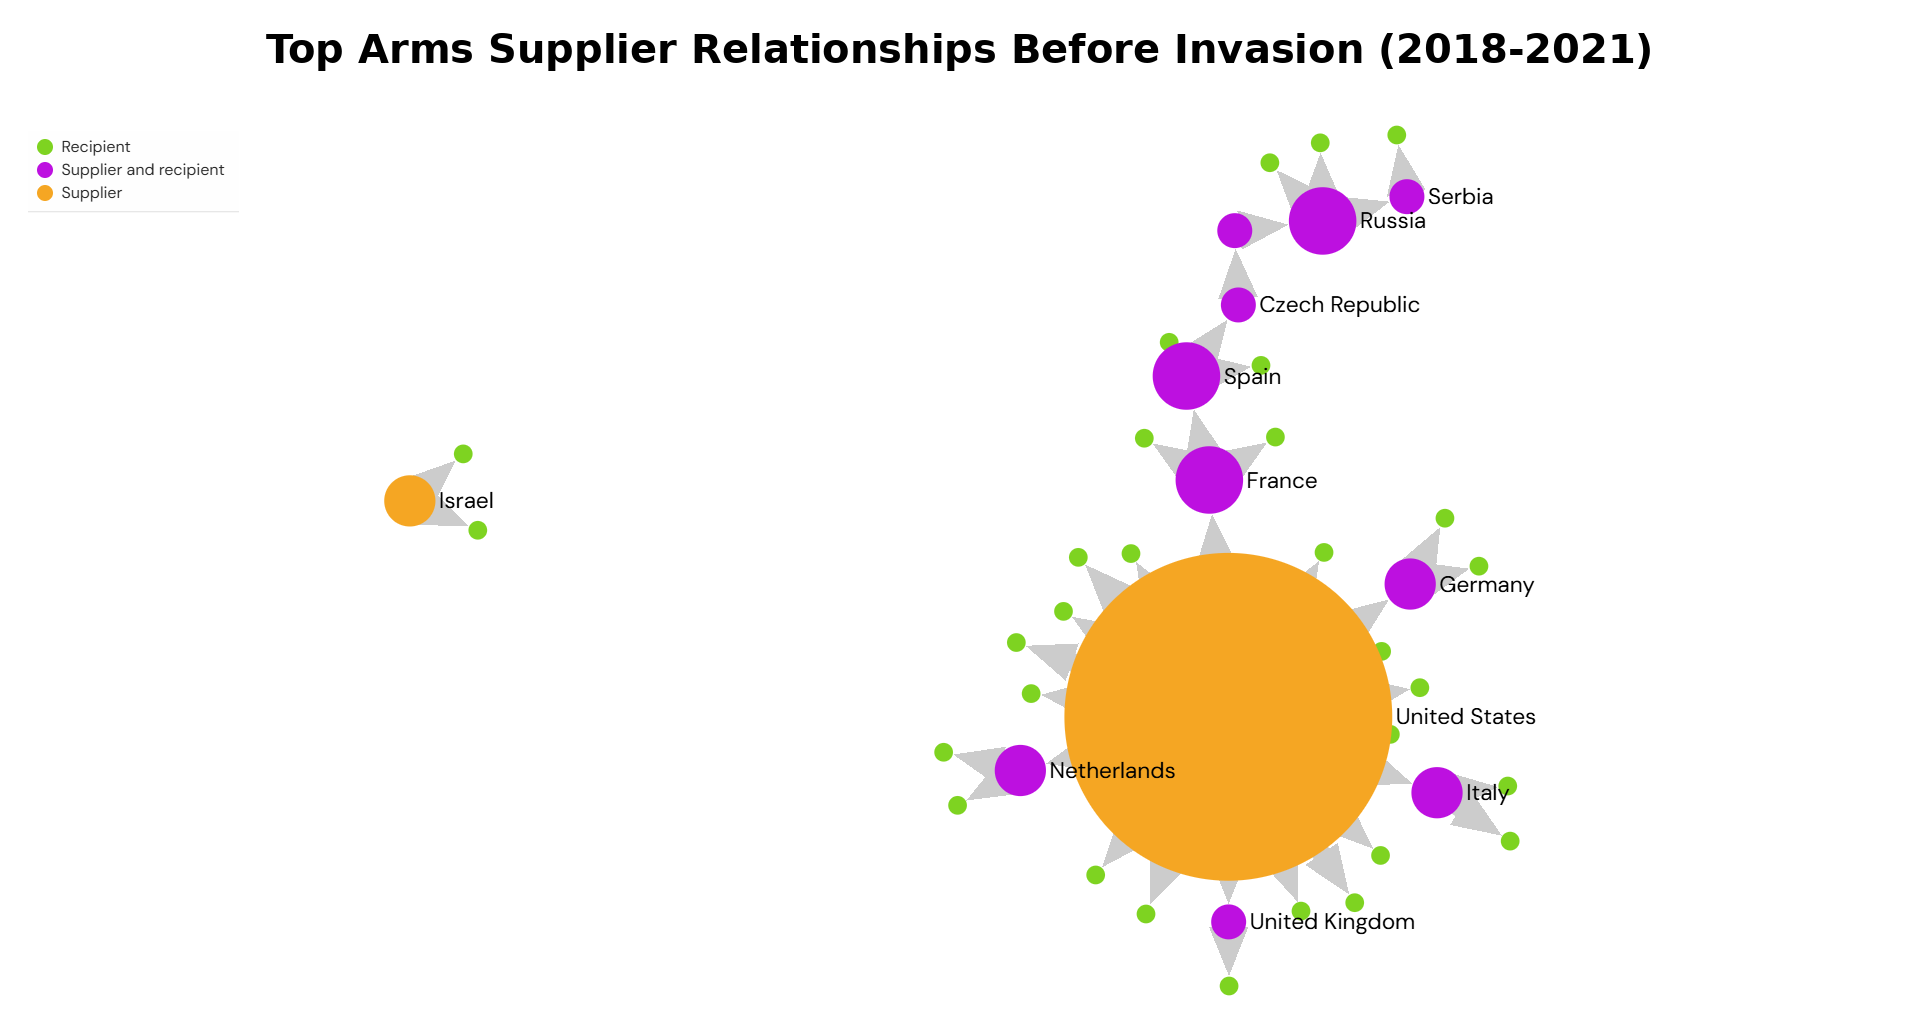

In [5]:
display(
    Image(
        filename="top_arms_supplier_relationships_before_invasion_2018_2021.png",
        width=1100
    )
)

*Figure 4:*



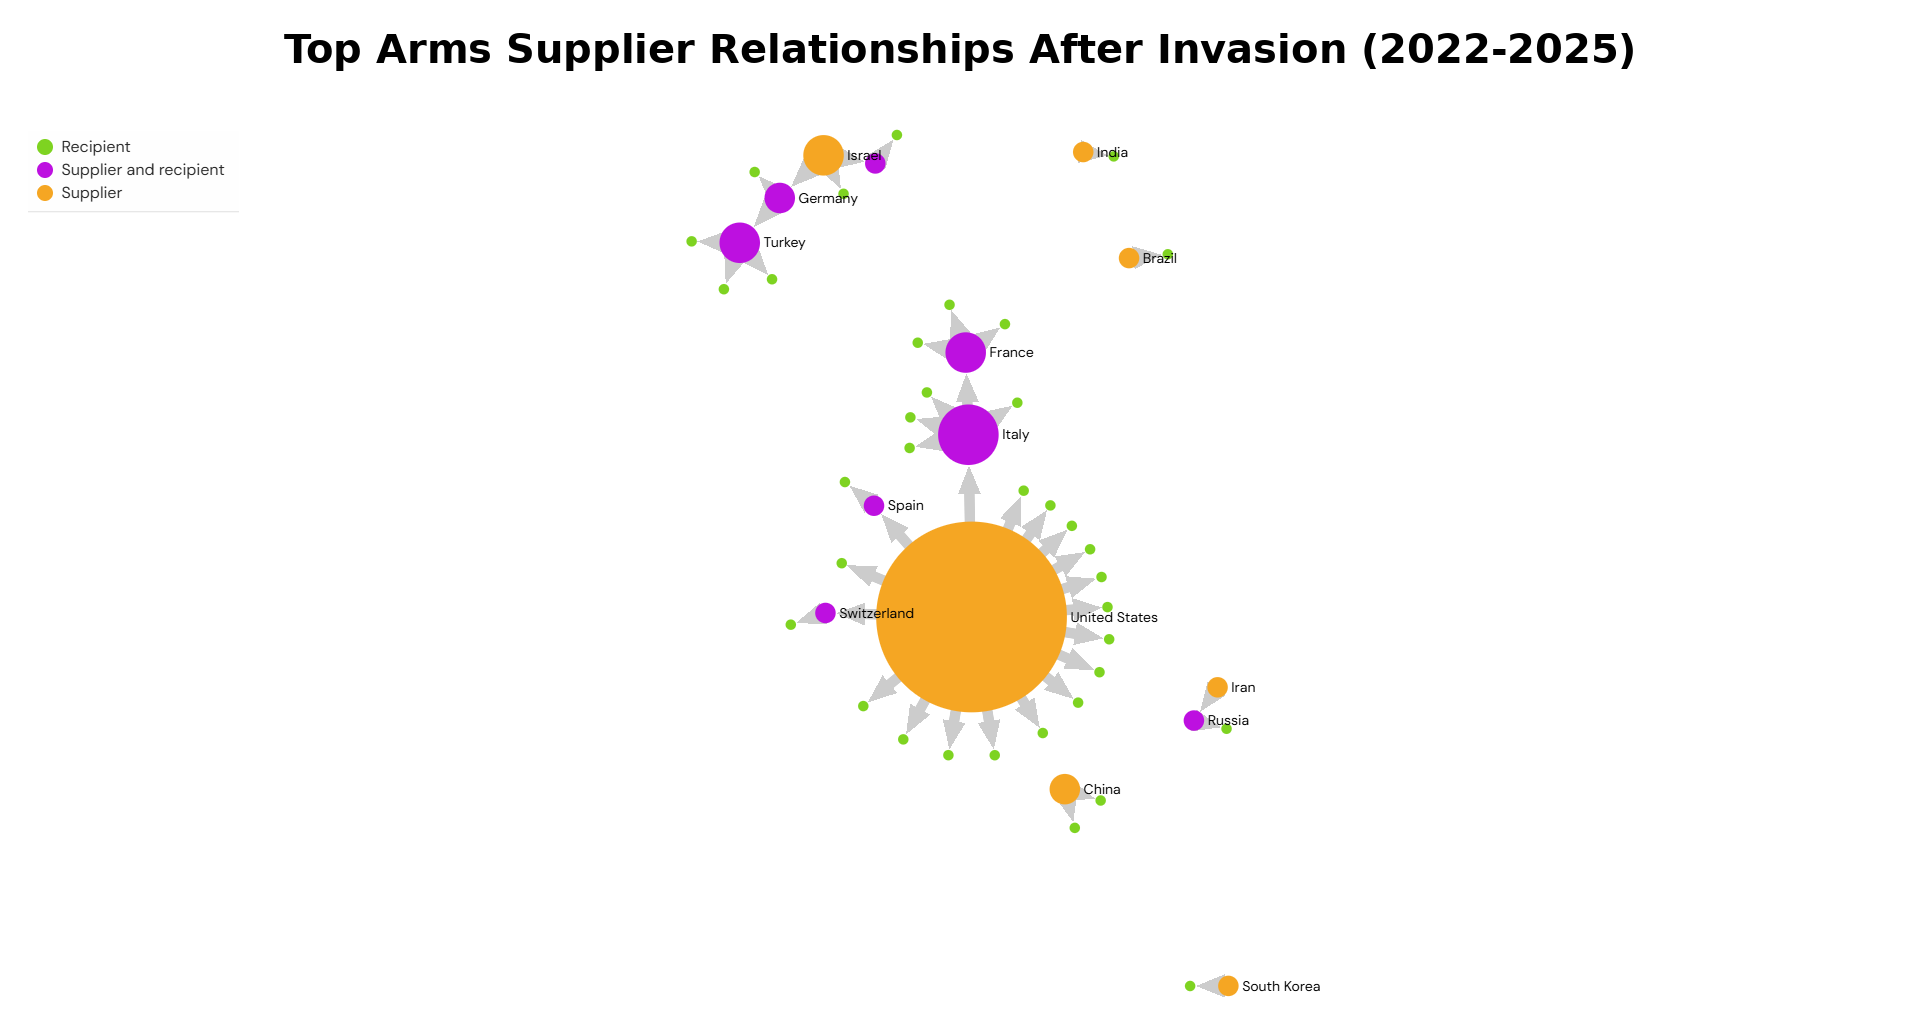

In [6]:
display(
    Image(
        filename="top_arms_supplier_relationships_after_invasion_2022_2025.png",
        width=1100
    )
)

Gephi is a powerful visualization tool for building network models. Perfect for visualizing supplier-recipient relationships, it gives us unique insight into how Russia’s 2022 invasion of Ukraine disrupted a surprisingly well-connected European arms network.

With the invasion beginning in 2022, we have 4 full years of post-invasion data (2022-2025). Using these 4 years, we look at the total TIV units imported by every European country to determine its top supplier (SIPRI, n.d.). This metric relies on *plurality*. For example, a country could have a very diverse supplier profile with their top supplier only making up 30% of their imports. But that top supplier would still be the most important defense relationship—and it would be reflected in this metric. Figure 3 shows the 4 years leading up to the war (2018-2021) to give us an idea of what the supplier-recipient relationships looked like before the disruption.

In Figure 3, we see a remarkable amount of connectedness amongst nearly all European countries and their suppliers. The United States stands out as a giant top supplier for the most countries at 19. Even *Russia* is connected in this arms supply network, although for unusual reasons. To our surprise, Russia’s top arms supplier before the outbreak of war was in fact *Ukraine*. This is due to a concept called *dual-use technology,* where a technology sold for civilian purposes can be repurposed for military use. SIPRI’s 2018 data shows TIV unit transfers from Ukraine to Russia (SIPRI, n.d.). Though supply contracts were terminated between Russia and Ukraine in 2014, transferred parts (Antonov An-148-100E transport jet parts) assembled in Russia had licensing tied to a defense company based in Ukraine, with the transfer not being recorded by SIPRI until 2018 (UNIAN, 2019). Evidence is unclear as to whether Russia has used these transport jets for military purposes since the start of the invasion, but the example stands as a reminder that dual-use technology creates an incredible amount of overlap between the aerospace and defense industries.

Figure 4 shows this same European arms supply network become incredibly fragmented after the outbreak of the full-scale invasion. We see the existence of 7 unconnected networks: *the United States, Israel, India, Brazil, Iran, China,* and *South Korea.* The disparity in connectedness between the pre-war Figure 3 and the post-invasion Figure 4 shows us a European arms supply network that has splintered, with governments realigning their priorities and alliances.

Figure 3’s pre-war arms network’s surprising connectedness is not coincidental. Students of history may remember the First World War as a confounding conflict with a complicated list of reasons for its beginning. But history teachers hold on to a single foundational axiom that best sums up the powder keg that began the Great War: The system of alliances that had kept Europe at peace had broken down. We can view the remarkable connectedness of the 2018-2021 European arms network modeled in Figure 3 as an individual system of alliances exclusive to weaponry and defense. It cannot be inferred that the fragmentation that is reflected in the post-invasion Figure 4 will begin a global conflict like the First World War. But it is a grave illustration of the seriousness and significance of this current conflict: Europe’s first large, conventional land war since the World War period.


##5. Histograms, Heatmap, and Pearson Correlation Coefficients

Digging into the coding section, we start exploring our data with some simple statistics and visualizations.

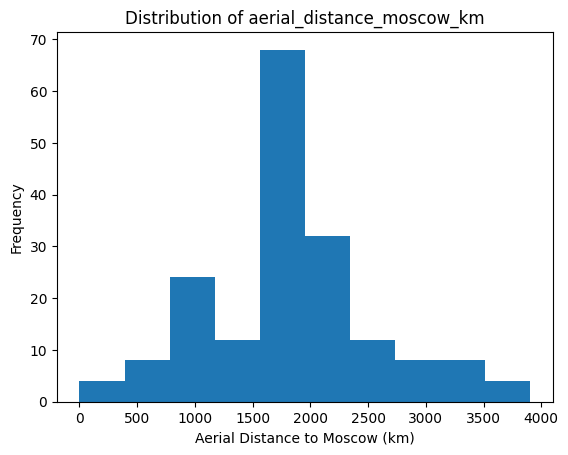

In [7]:
# Our only feature that follows a Normal distribution

plt.hist(df["aerial_distance_moscow_km"])
plt.title("Distribution of aerial_distance_moscow_km")
plt.xlabel("Aerial Distance to Moscow (km)")
plt.ylabel("Frequency")
plt.show()

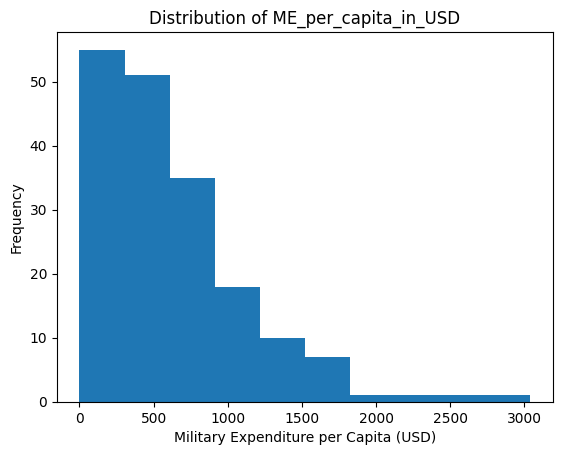

In [8]:
# An example of a feature with a skewed distribution.
# Shows us that a lot of European countries spend very little per capita.

plt.hist(df["ME_per_capita_in_USD"])
plt.title("Distribution of ME_per_capita_in_USD")
plt.xlabel("Military Expenditure per Capita (USD)")
plt.ylabel("Frequency")
plt.show()

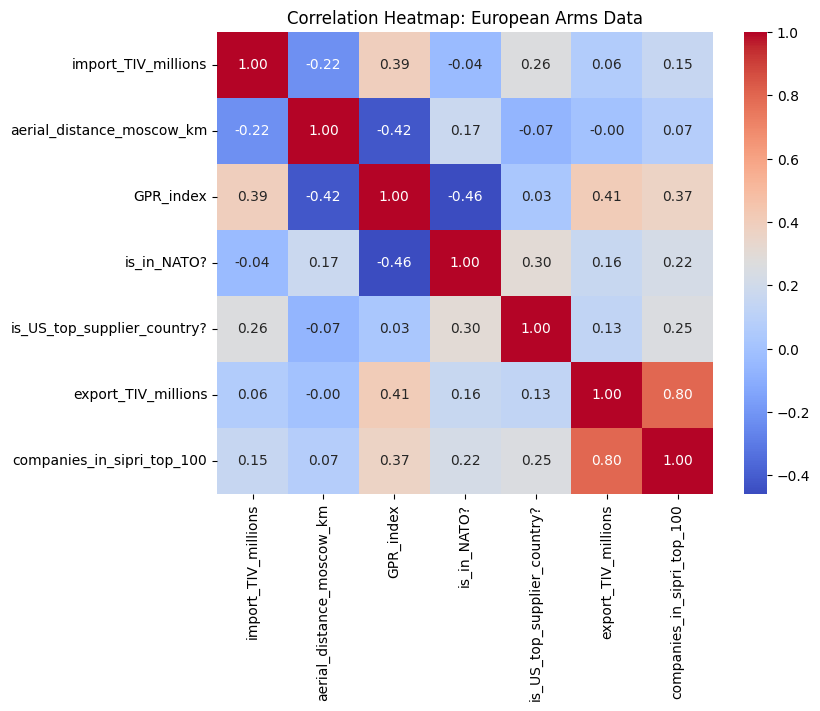

In [9]:
# Heatmap of our features

features = [
    'import_TIV_millions',
    'aerial_distance_moscow_km',
    'GPR_index',
    'is_in_NATO?',
    'is_US_top_supplier_country?',
    'export_TIV_millions',
    'companies_in_sipri_top_100'
]

heatmap_df = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: European Arms Data')
plt.show()

In [10]:
# Pearson Correlation Coefficients

# Filter down to only the year 2023, and only NATO members.
NATO_2023 = df[(df["year"] == 2023) & (df["is_in_NATO?"] == 1)]

distance_vs_ME = (
    NATO_2023["aerial_distance_moscow_km"]
    .corr(NATO_2023["ME_spending_%_GDP_lead_1_year"])
)

GPR_vs_top100 = (
    NATO_2023["GPR_index"]
    .corr(NATO_2023["companies_in_sipri_top_100"])
)

corr_table = pd.DataFrame({
    "Description": [
        "Distance From Moscow vs. ME % GDP (NATO, 2024)",
        # The reason that the label says (NATO, 2024) is that we're using
        # ME_spending_%_GDP_lead_1_year in the correlation.
        "GPR Index vs. Top 100 Defense Companies (NATO, 2023)",
    ],
    "Pearson Correlation": [
        distance_vs_ME,
        GPR_vs_top100
    ]
})

print(corr_table)

                                         Description  Pearson Correlation
0     Distance From Moscow vs. ME % GDP (NATO, 2024)            -0.672786
1  GPR Index vs. Top 100 Defense Companies (NATO,...             0.881429


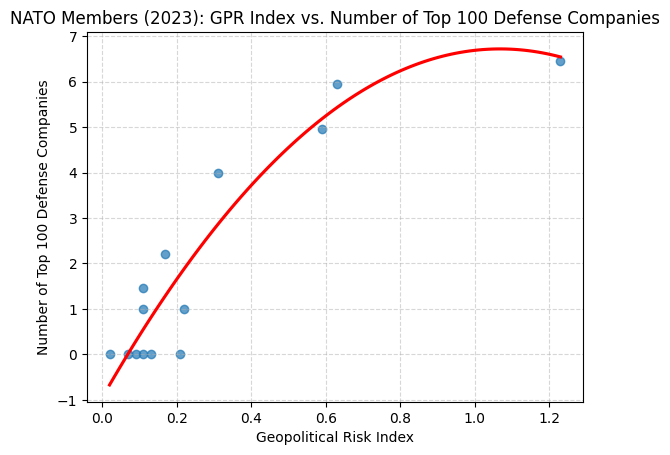

In [11]:
# We're going to plot the better of the two correlations.
# This will be polynomial regression.

sns.regplot(
    data=NATO_2023,
    x="GPR_index",
    y="companies_in_sipri_top_100",
    order=2,   # This will make it look like 2nd-degree polynomial regression
    ci=None,
    scatter_kws={"alpha": 0.7},
     line_kws={"color": "red"}
)

plt.xlabel("Geopolitical Risk Index")
plt.ylabel("Number of Top 100 Defense Companies")
plt.title("NATO Members (2023): GPR Index vs. Number of Top 100 Defense Companies")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

We explore this here instead of in the regression section because we have enough data points to make a neat visualization, but not enough for the more complex regression modeling coming later. GPR Index as a feature has lots of missingness, as not all European countries were given values.

##6. Regression Modeling: The Year That Rebalanced Europe

*How 2023 Became a Powerful Predictor of Military Spending*

In [12]:
from pycaret.regression import *

# We'll build the first model pipeline.

regression_pipeline = setup(
    data=df,
    target='ME_spending_%_GDP',
    categorical_features=['year'],
    ignore_features=[
        'GPR_index',
        'companies_in_sipri_top_100',
        'is_in_NATO?',
        'export_coverage_ratio',
        'export_TIV_millions',
        'is_US_top_supplier_country?',
        'top_supplier_country',
        'import_TIV_millions',
        'country',
        'ME_spending_%_GDP_lead_1_year',
        'ME_per_capita_in_USD',
        'ME_%_gov_budget',
        'ME_spending_%_GDP_growth_rate',
        'import_growth_rate',
        'import_export_ratio',
        'export_growth_rate',
    ],
    numeric_imputation='median',
    #categorical_imputation='constant',
    normalize=True,
    session_id=42,
    train_size=0.8,
    fold = 5
)

,Description,Value
0,Session id,42
1,Target,ME_spending_%_GDP
2,Target type,Regression
3,Original data shape,"(180, 19)"
4,Transformed data shape,"(180, 6)"
5,Transformed train set shape,"(144, 6)"
6,Transformed test set shape,"(36, 6)"
7,Ignore features,16
8,Numeric features,1
9,Categorical features,1


In [13]:
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
xgboost,Extreme Gradient Boosting,0.0048,0.0001,0.0084,0.8164,0.0074,0.2512,0.1520
huber,Huber Regressor,0.0116,0.0017,0.0320,0.0284,0.0278,0.5901,0.0660
lasso,Lasso Regression,0.0147,0.0018,0.0342,-0.3794,0.0300,1.0405,0.0880
dummy,Dummy Regressor,0.0147,0.0018,0.0342,-0.3794,0.0300,1.0405,0.0940
llar,Lasso Least Angle Regression,0.0147,0.0018,0.0342,-0.3794,0.0300,1.0405,0.0560
en,Elastic Net,0.0147,0.0018,0.0342,-0.3794,0.0300,1.0405,0.0540
omp,Orthogonal Matching Pursuit,0.0157,0.0017,0.0344,-0.7290,0.0293,0.8826,0.0600
br,Bayesian Ridge,0.0153,0.0018,0.0344,-0.7490,0.0297,0.9028,0.0540
et,Extra Trees Regressor,0.0154,0.0021,0.0364,-0.8341,0.0319,0.6916,0.1500
knn,K Neighbors Regressor,0.0152,0.0019,0.0370,-1.0720,0.0325,0.7914,0.0640


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

In [14]:
xgboost_model = create_model('xgboost')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0029,0.0000,0.0040,0.7350,0.0040,0.2545
1,0.0039,0.0000,0.0050,0.7872,0.0049,0.2475
2,0.0058,0.0002,0.0130,0.9650,0.0106,0.1597
3,0.0052,0.0001,0.0084,0.6333,0.0081,0.3630
4,0.0061,0.0001,0.0118,0.9616,0.0094,0.2313
Mean,0.0048,0.0001,0.0084,0.8164,0.0074,0.2512
Std,0.0012,0.0001,0.0036,0.1298,0.0026,0.0653


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [15]:
tuned_xgboost = tune_model(xgboost_model, choose_better=True)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0031,0.0000,0.0035,0.8035,0.0034,0.2674
1,0.0038,0.0000,0.0045,0.8242,0.0044,0.2701
2,0.0131,0.0025,0.0501,0.4837,0.0400,0.2073
3,0.0045,0.0001,0.0078,0.6831,0.0075,0.2732
4,0.0037,0.0000,0.0051,0.9928,0.0050,0.2112
Mean,0.0056,0.0005,0.0142,0.7575,0.0121,0.2458
Std,0.0037,0.0010,0.0180,0.1688,0.0140,0.0300


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [16]:
from pycaret.regression import get_config

X_train = get_config('X_train')
X_train.head()

,year,aerial_distance_moscow_km
117,2023,2146.979980
65,2023,1608.829956
67,2025,1608.829956
31,2025,1777.410034
12,2022,1927.380005


In [17]:
X_train_process = get_config('X_train_transformed')
X_train_process.head()

,year_2023.0,year_2025.0,year_2022.0,year_2024.0,aerial_distance_moscow_km
117,1.834022,-0.609449,-0.566658,-0.588043,0.319107
65,1.834022,-0.609449,-0.566658,-0.588043,-0.452703
67,-0.545250,1.640825,-0.566658,-0.588043,-0.452703
31,-0.545250,1.640825,-0.566658,-0.588043,-0.210927
12,-0.545250,-0.609449,1.764734,-0.588043,0.004159


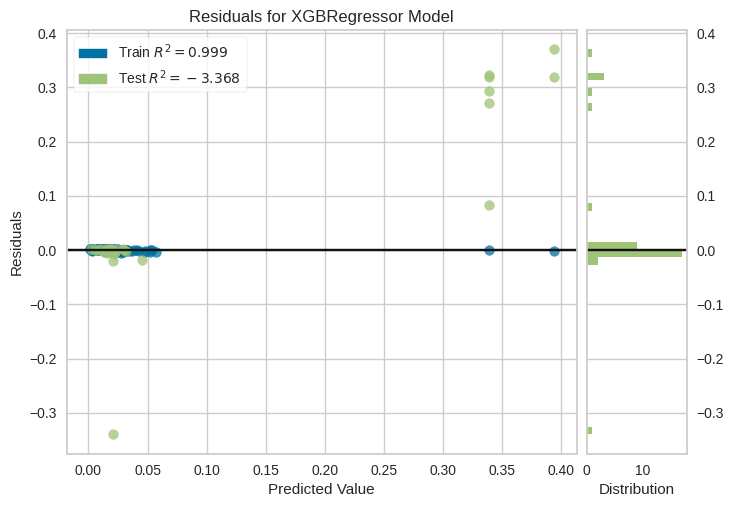

In [18]:
plot_model(tuned_xgboost, plot='residuals')

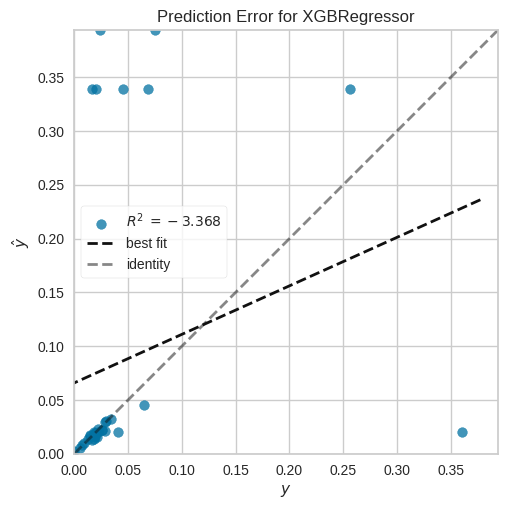

In [19]:
plot_model(tuned_xgboost, plot='error')

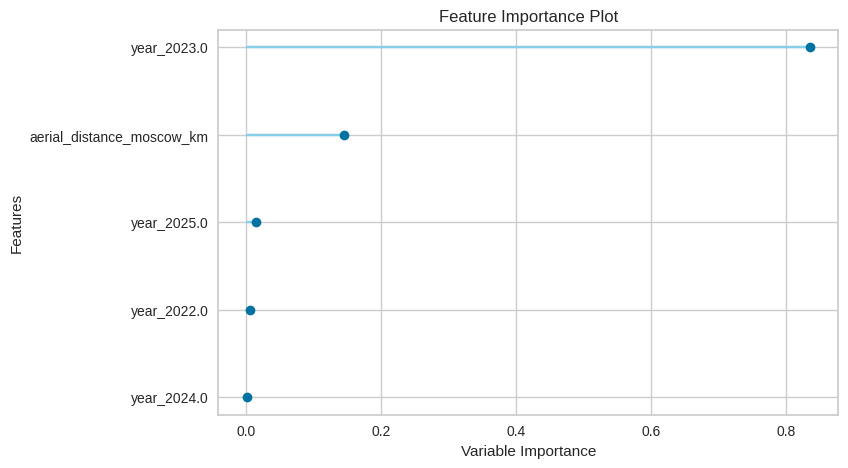

In [20]:
plot_model(tuned_xgboost, plot='feature')

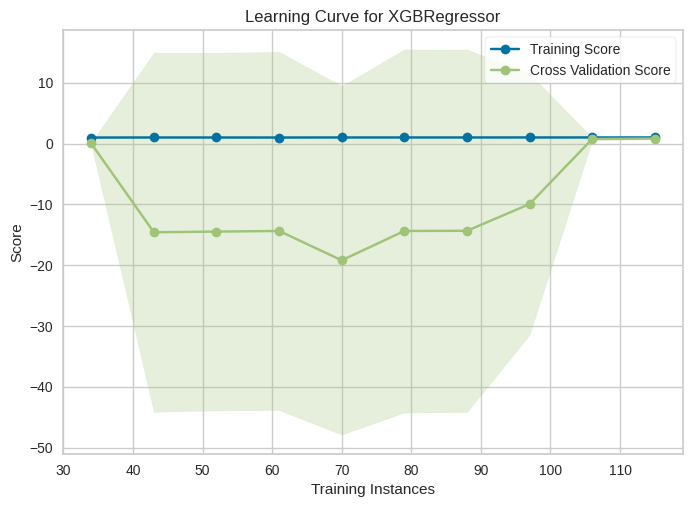

In [21]:
plot_model(tuned_xgboost, plot="learning")

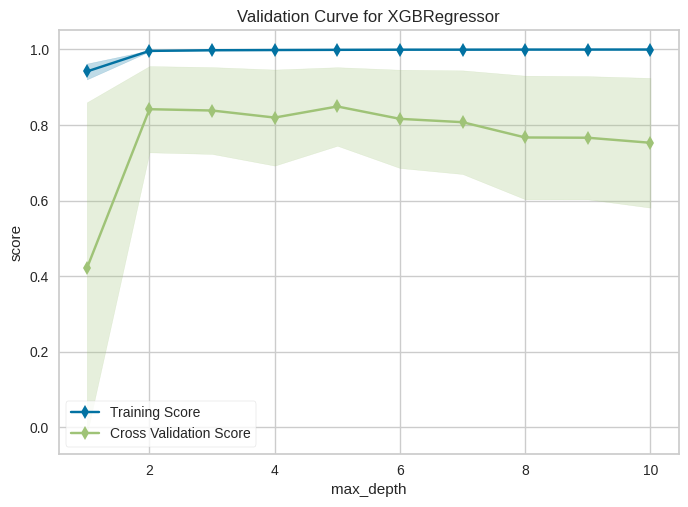

In [22]:
plot_model(tuned_xgboost, plot="vc")

Following the February 2022 invasion of Ukraine, European governments braced for a rebalancing of the world order. German Chancellor Olaf Scholz deemed this moment to be Europe’s *Zeitenwende*—a historic turning point (Cepparulo & Pasimeni, 2024).

As governments create central budgets in the year prior based on geopolitical risks encountered recently, it can be derived that a massive and unpredicted reshuffling of risk in 2022 would be first noticed in most European government spending patterns in calendar year 2023. We see this global reshuffling play out precisely in our regression model. When using military expenditure as a share of GDP as our target, we are left with 2 features that are of the most importance: data from calendar year 2023 (> 80%) and the aerial distance that a European capital sits from Moscow (~15%). With 4 years of war sampled in this dataset, (2022 through 2025,) it would be understandable that the year 2023 would bear the most importance, as it is the first year in which central budgets across Europe were given a chance to plan for and redirect capital toward growing uncertainty in the East.

To explain why our additional feature *aerial_distance_moscow_km* played significant importance, we need to explain the inspiration behind its inclusion in the dataset. Knezović and Tkalec (2025) posed an observation: For every 100 kilometers that a NATO member’s capital is located farther from Moscow, their average yearly military expenditure as a percentage of GDP has an associated decrease of 0.02 percentage points. Knezović and Tkalec (2025) found that Western NATO members, protected by geography, distance, and buffer states, were much less likely to see the rise of Russian aggression as an immediate threat demanding significant defense budget changes.

Extreme Gradient Boosting proved to be the best performing regression model, with a MAE of 0.0048, MSE of 0.0001, a RMSE of 0.0084, and an R-squared of 0.82. It is important to note that the target, *ME_spending_%_GDP,* is stored as a proportion: 0.03 meaning 3% of GDP. Therefore, an MAE of 0.0048 means approximately 0.48 percentage points, and not 0.0048 percentage points.

Extreme Gradient Boosting was uniquely positioned to excel where other regression techniques failed, as this was a fairly small dataset, (only 180 records,) and Extreme Gradient Boosting is known to handle interactions well. Boosted tree structured models are better at modeling nonlinear relationships, as well as working with the necessary inclusion of outliers, (Ukraine and Russia,) whereas other regression models could easily be pulled astray.


##7. Classification Modeling I: United States as Top Supplier Country

In [23]:
from pycaret.classification import *

In [24]:
classification_pipeline = setup(
    data=df,
    target='is_US_top_supplier_country?',
    session_id=42,
    normalize=True,
    ignore_features=[
        'country',
        'top_supplier_country',
        'year',
        'ME_spending_%_GDP_lead_1_year'
    ],
    numeric_imputation='mean',
    categorical_imputation='mode',
    fix_imbalance=True,
    fold=5
)

,Description,Value
0,Session id,42
1,Target,is_US_top_supplier_country?
2,Target type,Binary
3,Original data shape,"(180, 19)"
4,Transformed data shape,"(221, 15)"
5,Transformed train set shape,"(166, 15)"
6,Transformed test set shape,"(55, 15)"
7,Ignore features,4
8,Numeric features,14
9,Rows with missing values,70.0%


In [25]:
# Compare all models

best_model1 = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7520,0.7863,0.5778,0.6460,0.6055,0.4273,0.4317,0.1540
rf,Random Forest Classifier,0.7440,0.7969,0.5306,0.6514,0.5733,0.3981,0.4095,0.2200
dt,Decision Tree Classifier,0.7120,0.6676,0.5278,0.5641,0.5374,0.3330,0.3372,0.0400
lr,Logistic Regression,0.7040,0.7032,0.7222,0.5624,0.6192,0.3897,0.4101,0.0440
qda,Quadratic Discriminant Analysis,0.7040,0.7040,0.5500,0.5811,0.5480,0.3338,0.3441,0.0400
lda,Linear Discriminant Analysis,0.7040,0.7130,0.7222,0.5624,0.6192,0.3897,0.4101,0.0400
ridge,Ridge Classifier,0.6960,0.7175,0.7222,0.5533,0.6139,0.3767,0.3974,0.0460
et,Extra Trees Classifier,0.6960,0.7738,0.5306,0.6169,0.5332,0.3178,0.3435,0.1740
ada,Ada Boost Classifier,0.6720,0.7266,0.5472,0.5681,0.5415,0.2938,0.3013,0.1220
xgboost,Extreme Gradient Boosting,0.6720,0.7237,0.5056,0.5081,0.4895,0.2558,0.2666,0.0800


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [26]:
gbc_model = create_model('gbc')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.8897,0.6250,0.7143,0.6667,0.5247,0.5271
1,0.7200,0.7941,0.5000,0.5714,0.5333,0.3346,0.3361
2,0.8800,0.9559,0.8750,0.7778,0.8235,0.7331,0.7360
3,0.7200,0.7431,0.4444,0.6667,0.5333,0.3446,0.3590
4,0.6400,0.5486,0.4444,0.5000,0.4706,0.1993,0.2001
Mean,0.7520,0.7863,0.5778,0.6460,0.6055,0.4273,0.4317
Std,0.0816,0.1399,0.1626,0.0993,0.1264,0.1846,0.1843


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [27]:
# Hyperparameter tuning

tuned_model1 = tune_model(gbc_model, optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.9191,0.7500,0.6667,0.7059,0.5552,0.5574
1,0.7200,0.8382,0.5000,0.5714,0.5333,0.3346,0.3361
2,0.8000,0.9191,0.8750,0.6364,0.7368,0.5819,0.6012
3,0.7200,0.8403,0.4444,0.6667,0.5333,0.3446,0.3590
4,0.6400,0.5347,0.3333,0.5000,0.4000,0.1573,0.1639
Mean,0.7360,0.8103,0.5806,0.6082,0.5819,0.3947,0.4035
Std,0.0599,0.1423,0.2008,0.0643,0.1242,0.1570,0.1592


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


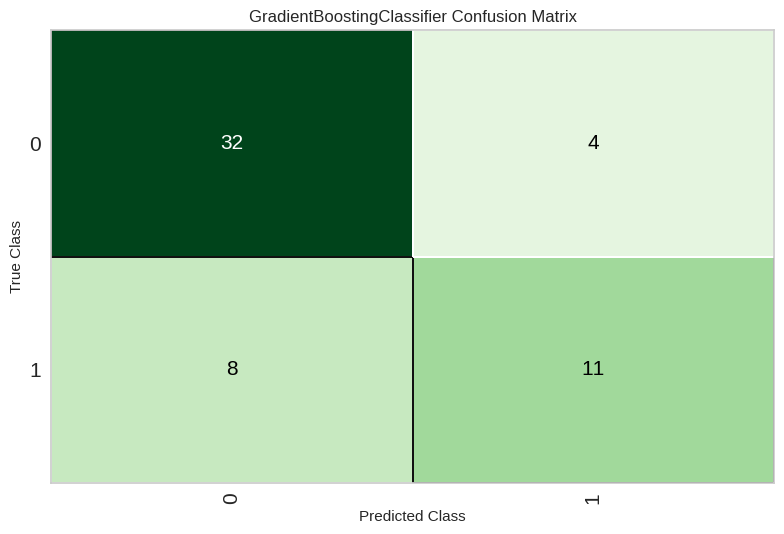

In [28]:
# Confusion Matrix

plot_model(tuned_model1, plot='confusion_matrix')

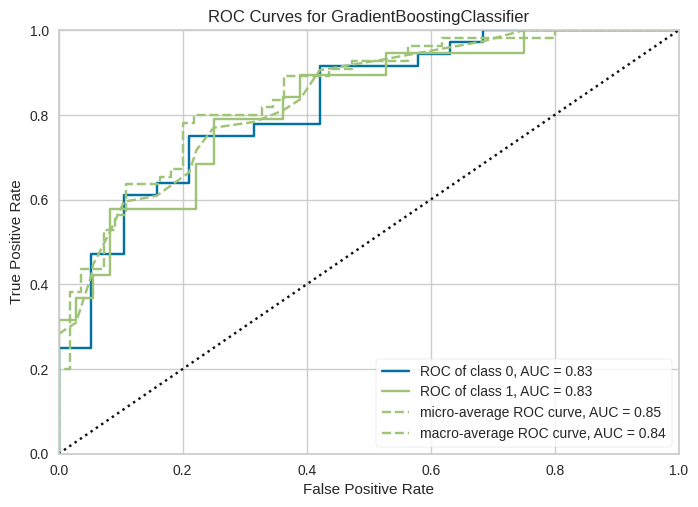

In [29]:
# ROC Curve

plot_model(tuned_model1, plot='auc')

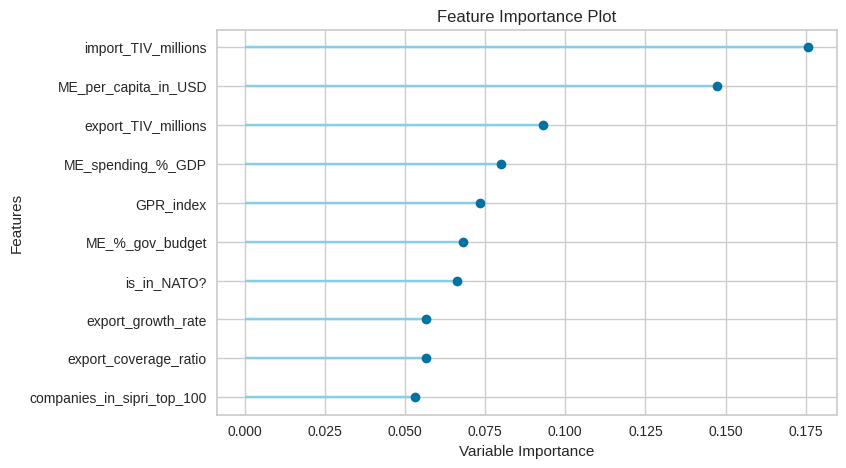

In [30]:
# Features that matter most

plot_model(tuned_model1, plot='feature')

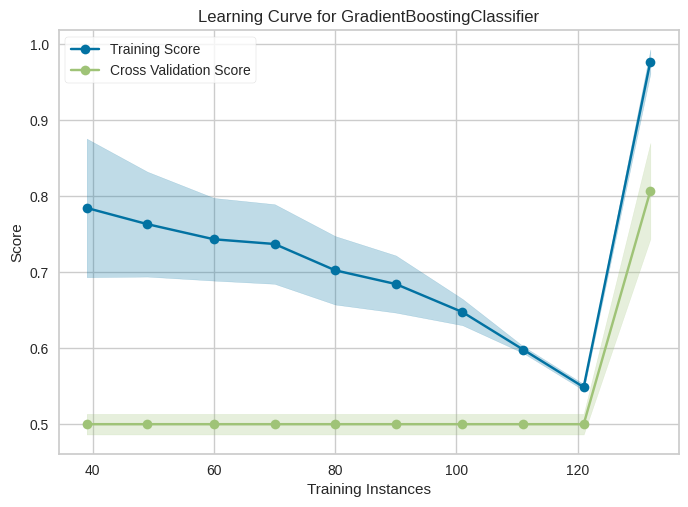

In [31]:
plot_model(tuned_model1, plot='learning')

The first attempt at building a classification model involves a binary classification as to whether the United States is a country’s top arms supplier.

The best performing model is a Gradient Boosting Classifier. Our tuned Gradient Boosting Classifier held an accuracy of 0.74, an AUC of 0.81, a recall of 0.58, a precision of 0.61, and an F1 score of 0.58.

Our most important features are import TIV units (0.18) and military expenditure per capita (~0.14). We can interpret our Feature Importance Plot as showing that this was an interaction-heavy model.


##8. Classification Modeling II: NATO Membership

In [32]:
classification_pipeline2 = setup(
    data=df,
    target='is_in_NATO?',
    session_id=42,
    normalize=True,
    ignore_features=[
        'country',
        'year',
        'ME_spending_%_GDP_lead_1_year'
    ],
    numeric_imputation='mean',
    categorical_imputation='mode',
    fix_imbalance=True,
    fold=5
)

,Description,Value
0,Session id,42
1,Target,is_in_NATO?
2,Target type,Binary
3,Original data shape,"(180, 19)"
4,Transformed data shape,"(217, 38)"
5,Transformed train set shape,"(162, 38)"
6,Transformed test set shape,"(55, 38)"
7,Ignore features,3
8,Numeric features,14
9,Categorical features,1


In [33]:
# Compare all models

best_model2 = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.9040,0.9472,0.8875,0.9589,0.9189,0.8026,0.8115,0.1620
gbc,Gradient Boosting Classifier,0.9040,0.9526,0.9132,0.9404,0.9247,0.7910,0.7961,0.2740
xgboost,Extreme Gradient Boosting,0.8800,0.9277,0.8882,0.9229,0.9018,0.7463,0.7538,0.1280
lightgbm,Light Gradient Boosting Machine,0.8800,0.9236,0.8875,0.9208,0.9036,0.7449,0.7463,0.1060
rf,Random Forest Classifier,0.8720,0.9188,0.8647,0.9342,0.8966,0.7291,0.7361,0.2440
et,Extra Trees Classifier,0.8720,0.8941,0.9125,0.8949,0.9006,0.7177,0.7269,0.3380
dt,Decision Tree Classifier,0.8560,0.8528,0.8640,0.9091,0.8850,0.6923,0.6967,0.0780
knn,K Neighbors Classifier,0.6800,0.7141,0.7412,0.7624,0.7500,0.3011,0.3039,0.1920
lr,Logistic Regression,0.6720,0.7002,0.6897,0.7793,0.7261,0.3124,0.3213,0.1600
ridge,Ridge Classifier,0.6640,0.6770,0.7022,0.7663,0.7241,0.2831,0.2956,0.0760


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [34]:
ada_model = create_model('ada')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9200,0.9653,0.9375,0.9375,0.9375,0.8264,0.8264
2,0.7600,0.8819,0.7500,0.8571,0.8000,0.5033,0.5104
3,0.8400,0.8889,0.7500,1.0000,0.8571,0.6835,0.7206
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
Mean,0.9040,0.9472,0.8875,0.9589,0.9189,0.8026,0.8115
Std,0.0933,0.0521,0.1146,0.0564,0.0793,0.1909,0.1845


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [35]:
# Hyperparameter tuning

tuned_model2 = tune_model(ada_model, optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9600,0.9861,1.0000,0.9412,0.9697,0.9110,0.9147
1,0.9200,0.9375,0.9375,0.9375,0.9375,0.8264,0.8264
2,0.8800,0.8542,0.9375,0.8824,0.9091,0.7331,0.7360
3,0.8000,0.8472,0.7500,0.9231,0.8276,0.5955,0.6138
4,0.9600,0.9926,1.0000,0.9444,0.9714,0.9049,0.9091
Mean,0.9040,0.9235,0.9250,0.9257,0.9231,0.7942,0.8000
Std,0.0599,0.0625,0.0919,0.0229,0.0530,0.1185,0.1136


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


Pycaret's tune_model() returns our original model, as the tuned models did not perform better.

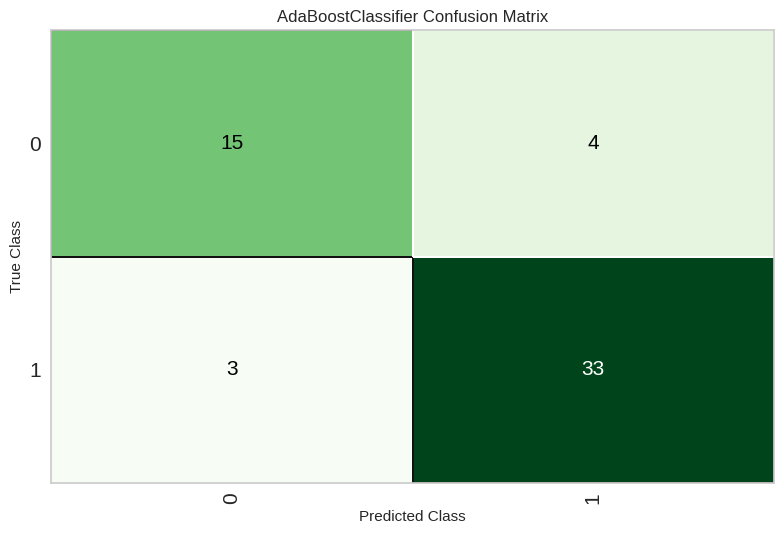

In [36]:
# Confusion Matrix

plot_model(tuned_model2, plot='confusion_matrix')

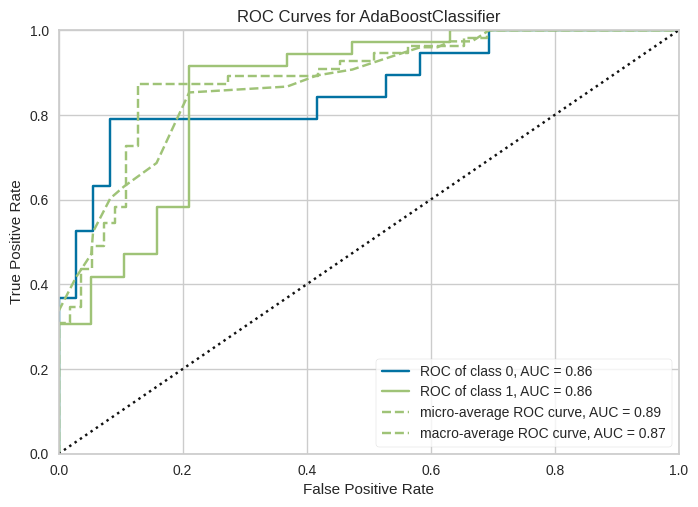

In [37]:
# ROC Curve

plot_model(tuned_model2, plot='auc')

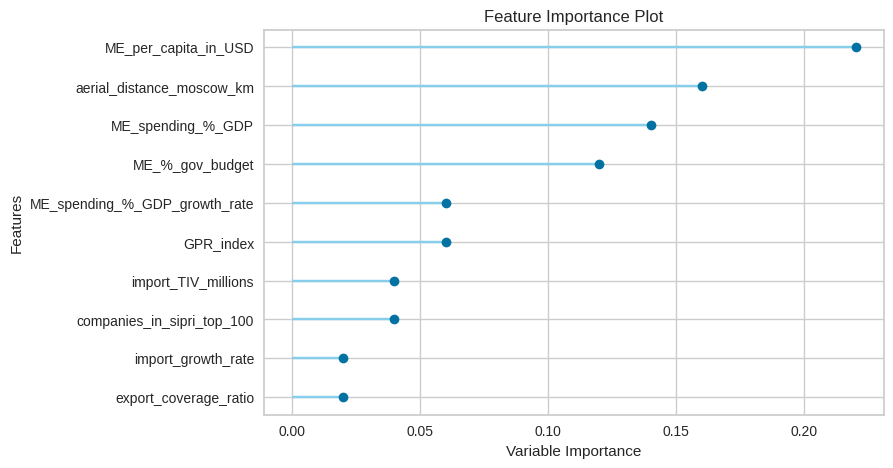

In [38]:
# Features that matter most

plot_model(tuned_model2, plot='feature')

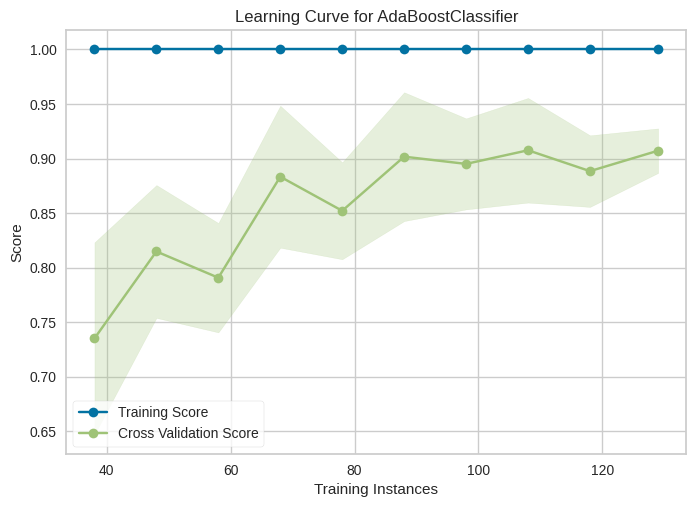

In [39]:
plot_model(tuned_model2, plot='learning')

The second attempt at building a classification model involves a binary classification as to whether a country is a member of NATO. One interesting caveat in this target data is that Finland became a NATO member in 2023, and Sweden a member in 2024.

The best performing model for this task was an AdaBoost Classifier. In contrast to other tree models like Extra Trees, AdaBoost builds decision trees in a sequence, having each new tree correct earlier classification mistakes. Our AdaBoost Classifier held an accuracy of 0.90, an AUC of 0.95, a recall of 0.89, a precision of 0.96, and an F1 score of 0.92. Across the board, this classifier performed better than our US Top Supplier Classifier on every metric. When using pycaret’s *tune_model()* function, we didn’t see any improvement over our original model.

Our most important features are Aerial Distance From Moscow (\~0.16) and Military Expenditure Per Capita (~0.23). It makes sense that distance from Moscow would correlate highly with NATO membership, as NATO was a Western alliance that slowly moved east. Many countries closer to Moscow (Georgia, Ukraine, Moldova, etc.) are not members, as Russia has prevented their acceptance into the alliance by claiming territory within their borders. NATO members also have expected military spending targets, so it would make sense that a high military expenditure per capita would correlate with NATO membership.

Decision Tree models usually come out on top when we pit several classification models against each other, but we can infer that the reason AdaBoost triumphed over other decision tree models was that the dataset had 2 very important features that together held a variable importance of around 0.39. With 2 features creating strong thresholds, AdaBoost’s sequential tree design was uniquely suited to pick up on small additional observations missed that were not geographical (aerial distance from Moscow) or financial (military expenditure). To  put it simply, all decision tree models picked up on *aerial_distance_moscow_km* and *ME_per_capita_in_USD* being the most important features, but AdaBoost was able to find minor tweaks for other features once it understood the major importance of the first two.


##9. Clustering and Dimensionality Reduction: Finding Commonalities

In [40]:
from pycaret.clustering import *

In [41]:
from scipy.cluster.hierarchy import dendrogram, linkage

# This function helps create all future dendrogram visualizations.

def dendro(title):
    dendrogram(linkage(get_config('X_transformed'), method='ward'))
    plt.xlabel('Observations')
    plt.ylabel('Ward Linkage Distance')
    plt.title(title)
    plt.show()

###9.1 Clustering Without Dimensionality Reduction

In [42]:
clustering_pipeline = setup(
    data=df,
    ignore_features=[
        'country',
        'year'
    ],
    numeric_imputation='mean',
    categorical_imputation='mode',
    normalize=True,
    normalize_method='zscore',
    session_id=42
)

,Description,Value
0,Session id,42
1,Original data shape,"(180, 19)"
2,Transformed data shape,"(180, 41)"
3,Ignore features,2
4,Numeric features,16
5,Categorical features,1
6,Rows with missing values,70.0%
7,Preprocess,True
8,Imputation type,simple
9,Numeric imputation,mean


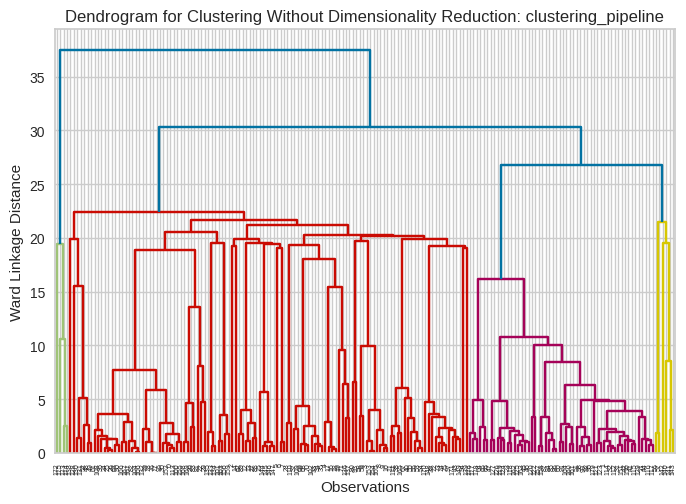

In [43]:
dendro("Dendrogram for Clustering Without Dimensionality "
       "Reduction: clustering_pipeline")

This looks atrocious compared to the results we'll get when we use dimensionality reduction.

In [44]:
print(models())

                                       Name  \
ID                                            
kmeans                   K-Means Clustering   
ap                     Affinity Propagation   
meanshift             Mean Shift Clustering   
sc                      Spectral Clustering   
hclust             Agglomerative Clustering   
dbscan     Density-Based Spatial Clustering   
optics                    OPTICS Clustering   
birch                      Birch Clustering   

                                                   Reference  
ID                                                            
kmeans                        sklearn.cluster._kmeans.KMeans  
ap         sklearn.cluster._affinity_propagation.Affinity...  
meanshift              sklearn.cluster._mean_shift.MeanShift  
sc              sklearn.cluster._spectral.SpectralClustering  
hclust     sklearn.cluster._agglomerative.AgglomerativeCl...  
dbscan                        sklearn.cluster._dbscan.DBSCAN  
optics                   

In [45]:
kmeans_model = create_model('kmeans', num_clusters=4)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2167,11.6329,1.1496,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [46]:
hclust_model = create_model('hclust', num_clusters=6)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.1231,13.0067,2.3107,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

The first attempt at clustering does not involve dimensionality reduction. It produced results that were not significant or meaningful. The dendrogram plot is unreadable, and we’re left with our best silhouette score being only 0.22 (a k-means clustering model).

###9.2 Linear PCA + Clustering

In [47]:
clustering_pipeline2 = setup(
    data=df,
    ignore_features=[
        'country',
        'year'
    ],
    numeric_imputation='mean',
    categorical_imputation='mode',
    normalize=True,
    normalize_method='zscore',
    session_id=42,
    pca=True,
    pca_method='linear',
    pca_components=2
)

,Description,Value
0,Session id,42
1,Original data shape,"(180, 19)"
2,Transformed data shape,"(180, 2)"
3,Ignore features,2
4,Numeric features,16
5,Categorical features,1
6,Rows with missing values,70.0%
7,Preprocess,True
8,Imputation type,simple
9,Numeric imputation,mean


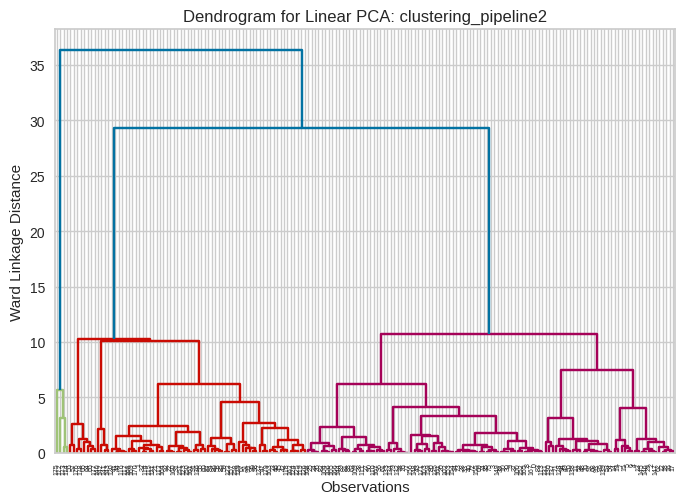

In [48]:
dendro("Dendrogram for Linear PCA: clustering_pipeline2")

In [49]:
kmeans_model2 = create_model('kmeans', num_clusters=3)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5384,297.2208,0.5493,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

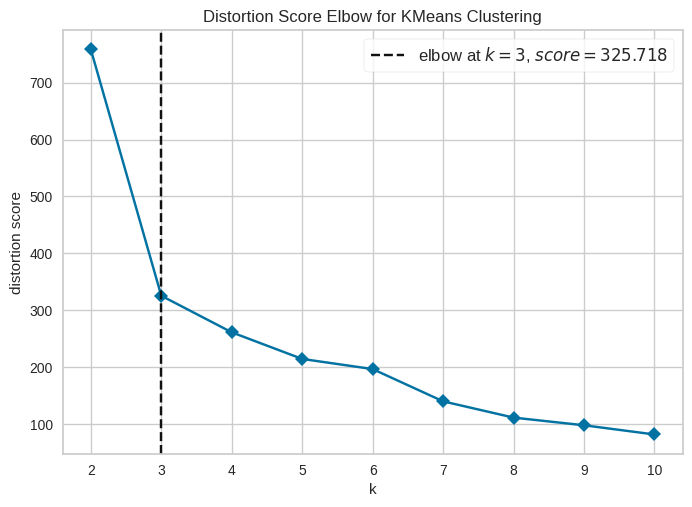

In [50]:
plot_model(kmeans_model2, plot='elbow')

In [51]:
plot_model(kmeans_model2, plot='cluster')

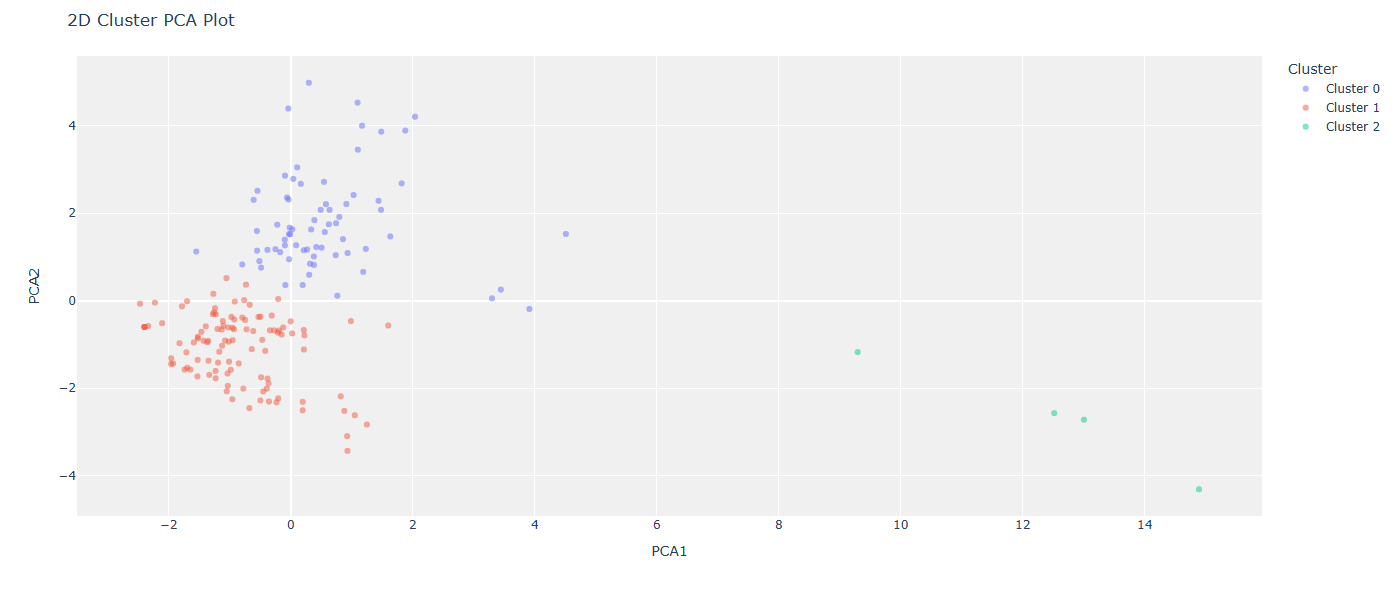

In [52]:
# The above cluster plot has trouble rendering correctly in most notebooks.
# Here's a .png file of what it looks like.

display(Image(filename="linear_PCA_kmeans.png", width=1100))

In [53]:
hclust_model2 = create_model('hclust', num_clusters=3)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5327,293.1130,0.5519,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

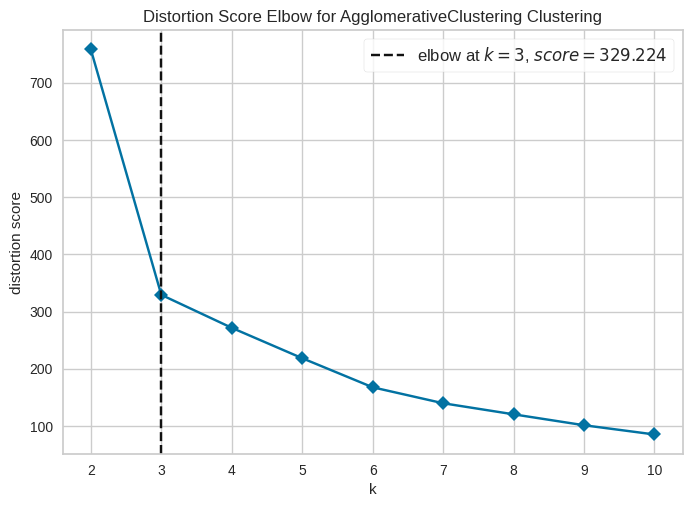

In [54]:
plot_model(hclust_model2, plot='elbow')

In [55]:
plot_model(hclust_model2, plot='cluster')

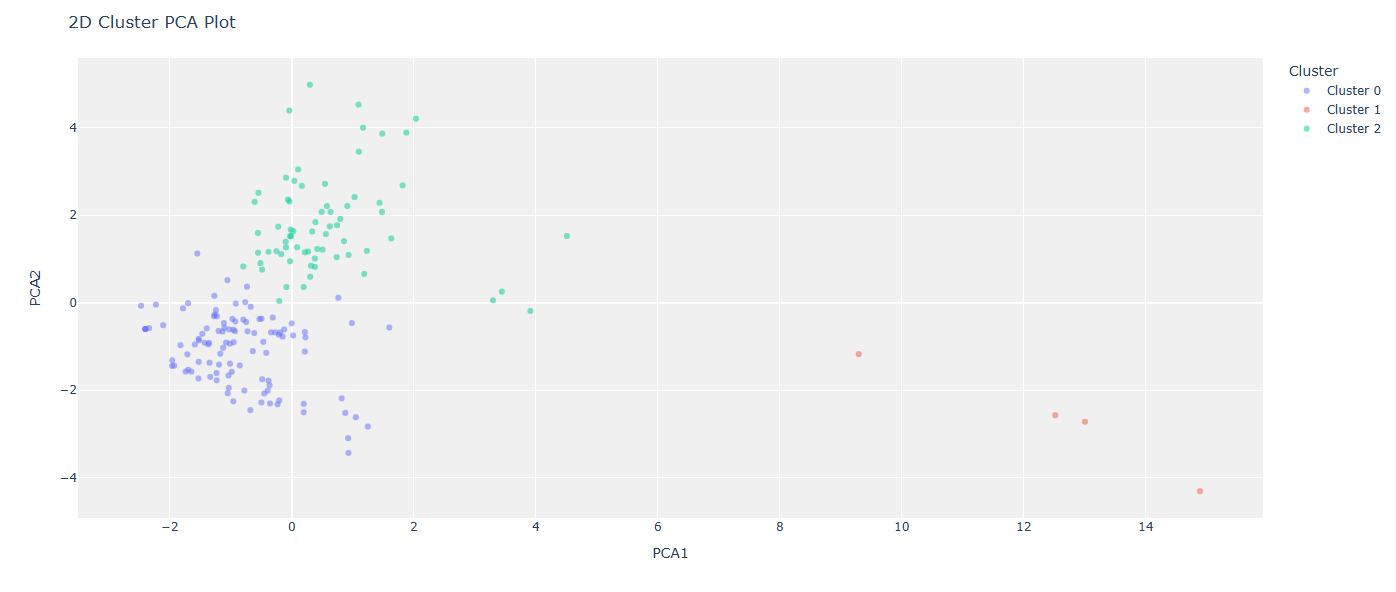

In [56]:
# The above cluster plot has trouble rendering correctly in most notebooks.
# Here's a .png file of what it looks like.

display(Image(filename="linear_PCA_hclust.png", width=1100))

The second clustering attempt uses linear PCA as its method of dimensionality reduction with improved results. When reducing our features down to two linear principal components, we get a dendrogram and distortion score elbow plot that favors 3 clusters (in both our k-means clustering model and our hierarchical agglomerative clustering model). When creating 2D scatter plots of the clusters, our k-means model and our hierarchical agglomerative model give us nearly identical results, with the only difference being small border data points between the top-left corner and bottom-left corner clusters. The top-left corner cluster groups together countries known to be major military import or export players: Russia, France, Turkey, United Kingdom, Poland, Italy, and Germany. The bottom-left corner cluster groups together countries that have relatively low military spending needs: Ireland, Iceland, Malta, Kosovo, etc. Ukraine, (a strong outlier as an active war zone,) becomes its own cluster. The k-means model gives us the slightly better of the two silhouette scores at 0.54.

###9.3 Nonlinear Kernel PCA + Clustering

In [57]:
clustering_pipeline3 = setup(
    data=df,
    ignore_features=[
        'country',
        'year'
    ],
    numeric_imputation='mean',
    categorical_imputation='mode',
    normalize=True,
    normalize_method='zscore',
    session_id=42,
    pca=True,
    pca_method='kernel',
    pca_components=2
)

,Description,Value
0,Session id,42
1,Original data shape,"(180, 19)"
2,Transformed data shape,"(180, 2)"
3,Ignore features,2
4,Numeric features,16
5,Categorical features,1
6,Rows with missing values,70.0%
7,Preprocess,True
8,Imputation type,simple
9,Numeric imputation,mean


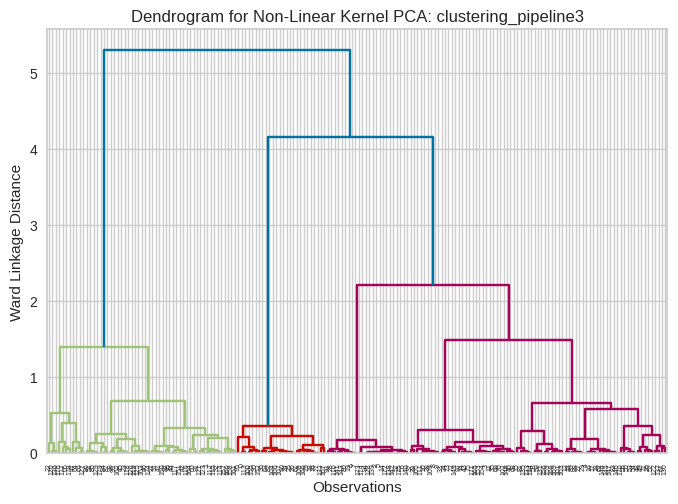

In [58]:
dendro("Dendrogram for Non-Linear Kernel PCA: clustering_pipeline3")

In [59]:
kmeans_model3 = create_model('kmeans', num_clusters=3)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.6504,349.3418,0.4634,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

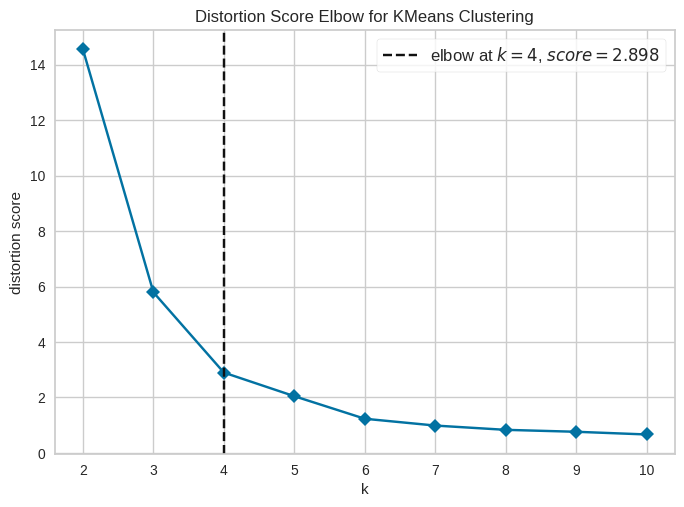

In [60]:
plot_model(kmeans_model3, plot='elbow')

In [61]:
plot_model(kmeans_model3, plot='cluster')

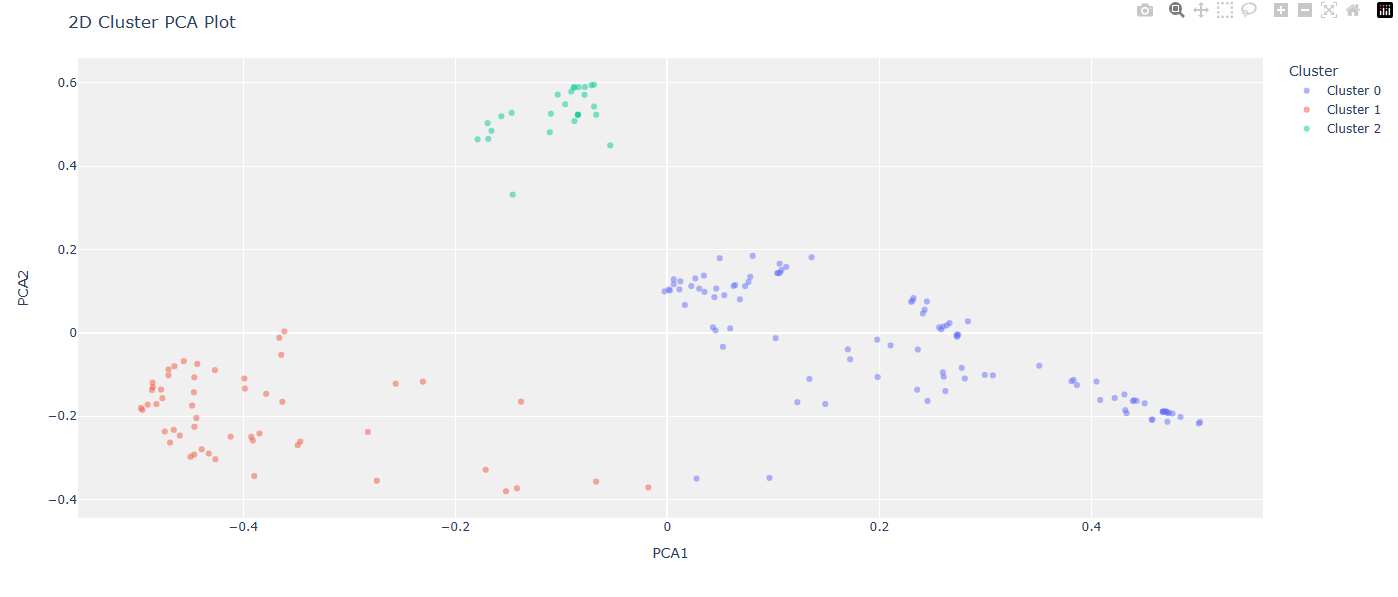

In [62]:
# The above cluster plot has trouble rendering correctly in most notebooks.
# Here's a .png file of what it looks like.

display(Image(filename="nonlinear_PCA_kmeans.png", width=1100))

In [63]:
hclust_model3 = create_model('hclust', num_clusters=3)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.6450,337.0767,0.4802,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

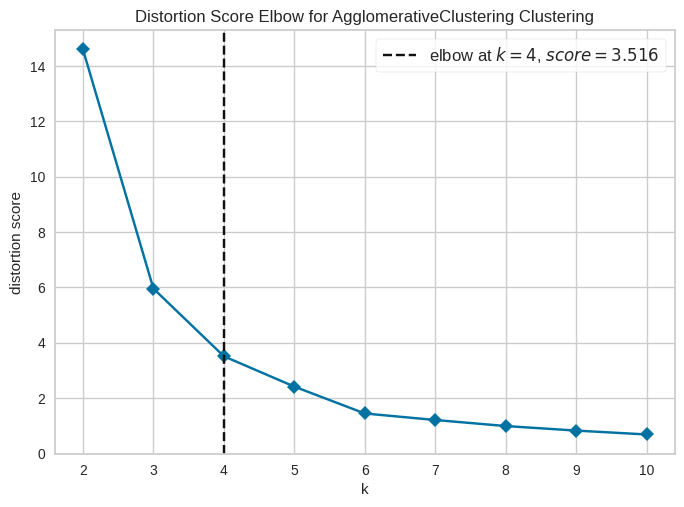

In [64]:
plot_model(hclust_model3, plot='elbow')

In [65]:
plot_model(hclust_model3, plot='cluster')

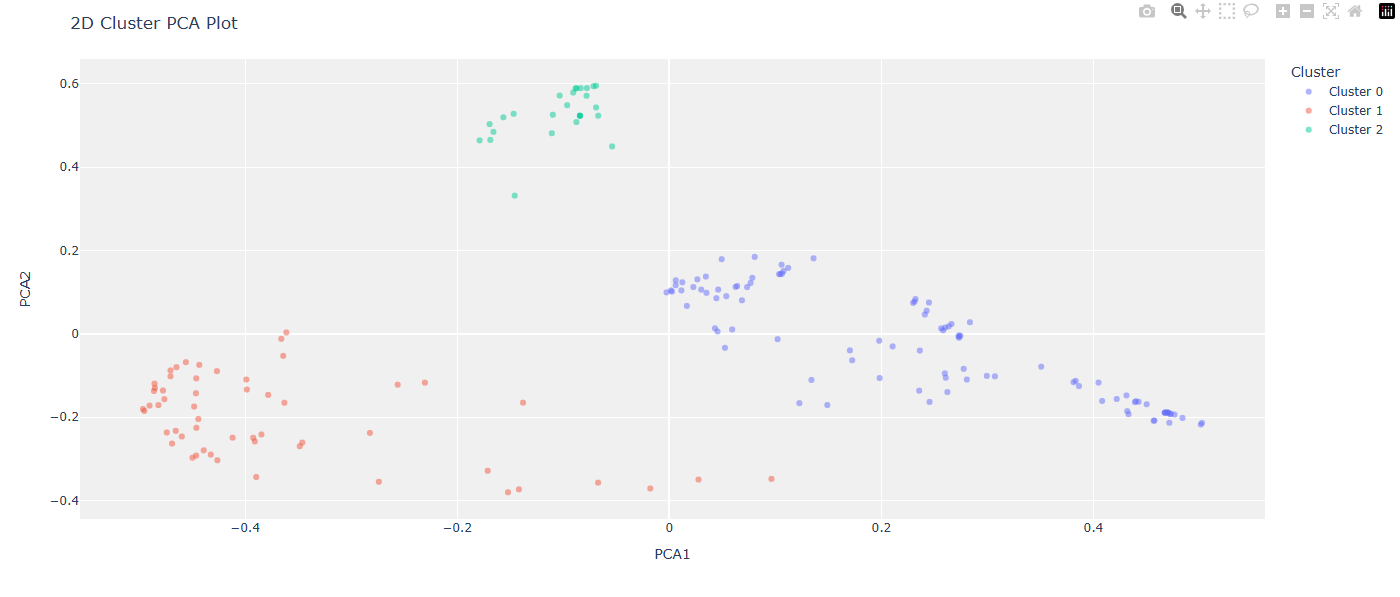

In [66]:
# The above cluster plot has trouble rendering correctly in most notebooks.
# Here's a .png file of what it looks like.

display(Image(filename="nonlinear_PCA_hclust.png", width=1100))

The third clustering attempt uses nonlinear kernel PCA as its method of dimensionality reduction. When reducing our features down to two non-linear principal components, we get a dendrogram that favors 3 clusters (in both our k-means model and our hierarchical agglomerative model). When creating 2D scatter plots of the clusters, our k-means model and our agglomerative model once again give us nearly identical results (the main difference being a few United Kingdom data points at the bottom center of both plots).  

The top-center of the scatter plot gives us our tightest cluster, composed mostly of smaller countries without much need in terms of military spending: Iceland, Portugal, Malta, Montenegro, etc. Many of these countries have periods of low or no arms imports. The bottom-right cluster includes countries with major military capabilities, (Russia, Ukraine, France, Poland, Turkey) but many additional countries that don’t form clear similarities. In the bottom-left corner, we get a cluster of many NATO members: Norway, Sweden, Lithuania, Netherlands, Slovakia, Germany, etc. Another commonality of this cluster is that most of the countries have the US as their top arms supplier. Both the k-means model and the agglomerative model give us our best resulting silhouette score: 0.65.

It should be noted that Ukraine’s data points were a massive outlier. When forcing the number of clusters to be exactly 2, all 4 of the plotted models preferred clustering Ukraine on its own, with the remaining cluster containing all other European countries. Ukraine is the main warfront, having transformed its economy into an engine to sustain a long-term, grinding war of attrition.


##10. References

Bachtiar, M., Ahmad, I., Sahabuddin, Z. A., & Trismadi, T. (2025). A comprehensive meta-analysis of determinants influencing military expenditure: New methodological insights and implications for defence budget allocation. *Statistika, Politika i Polityka, 16*(1), 87–103. https://doi.org/10.1515/spp-2024-0024

Caldara, D., & Iacoviello, M. (2022). Measuring geopolitical risk. *American Economic Review, 112*(4), 1194–1225. https://doi.org/10.1257/aer.20191823

Cepparulo, A., & Pasimeni, P. (2024). *Defence spending in the European Union* (European Economy Discussion Paper No. 199). European Commission, Directorate-General for Economic and Financial Affairs. https://doi.org/10.2765/883426

George, J., & Sandler, T. (2022). NATO defense demand, free riding, and the Russo-Ukrainian war in 2022. *Journal of Industrial and Business Economics, 49*, 783–806. https://doi.org/10.1007/s40812-022-00228-y

Google. (n.d.). *Google Maps.* https://maps.google.com

Knezović, S., & Tkalec, M. (2025). Defense spending, conflict and economic growth in Europe. *Peace Economics, Peace Science and Public Policy, 31*(4), 461–486. https://doi.org/10.1515/peps-2025-0004

Lebacher, M., Thurner, P. W., & Kauermann, G. (2021). A dynamic separable network model with actor heterogeneity: An application to global weapons transfers. *Journal of the Royal Statistical Society: Series A (Statistics in Society), 184*(1), 201–226. https://doi.org/10.1111/rssa.12620

Nawrocki, K. (2023, September 18). *Guardians of foreign interests.* Institute of National Remembrance.

Pamp, O., Lebacher, M., Thurner, P. W., & Ziegler, E. (2021). Explaining destinations and volumes of international arms transfers: A novel network Heckman selection model. *European Journal of Political Economy, 69*, Article 102033. https://doi.org/10.1016/j.ejpoleco.2021.102033


Stockholm International Peace Research Institute. (n.d.). SIPRI Arms Industry Database. https://www.sipri.org/databases/armsindustry

Stockholm International Peace Research Institute. (n.d.). SIPRI Arms Transfers Database. https://www.sipri.org/databases/armstransfers

Stockholm International Peace Research Institute. (n.d.). SIPRI Military Expenditure Database. https://www.sipri.org/databases/milex

Tian, N., Lopes da Silva, D., Béraud-Sudreau, L., Liang, X., Scarazzato, L., & Assis, A. (2023). Developments in military expenditure and the effects of the war in Ukraine. *Defence and Peace Economics, 34*(5), 547–562. https://doi.org/10.1080/10242694.2023.2221877

UNIAN. (2019, March 19). *Ukroboronprom refutes allegations of arms supplies to Russia*. https://www.unian.info/economics/10484022-ukroboronprom-refutes-allegations-of-arms-supplies-to-russia.html